# Phase 1 — Data cleaning & EDA (Citi Bike + Weather)

## Goal
We are combining:
- **Citi Bike trip data** from **2016 up to and including 2019**
- **Weather data** from **2016 up to and including 2019**

We are keeping **2019 separate** so that it can later serve as a future prediction year.

## Expected output
A dataset with hourly records including:
- `trip_count`
- Average trip duration
- Counts per `user_type`
- Weather features
- Time features such as `hour`, `day_of_week`, `month`, `season`

<!-- In deze notebook verwerken we de ruwe dataset. We doen dit foutloos in 3 fases:
1. **Omzetten naar Parquet:** Ruwe CSV's omzetten naar één efficiënt bestandsformaat.
2. **EDA op Ruwe Data:** Inzichten en uitschieters (outliers) in kaart brengen (Verplicht voor Deadline 1).
3. **Data Aggregatie:** De data opschonen en oprollen naar uurgemiddelden voor Machine Learning (Deadline 2). -->

## 1. Imports and general settings
We are loading the libraries required for data cleaning, aggregation, and visualizations.

In [ ]:
# %pip install polars
# %pip install duckdb
# %pip install folium
# %pip install fastparquet

In [24]:
import pandas as pd
import polars as pl
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
import difflib
import glob
import sys
import os
import gc
import folium
from folium.plugins import HeatMap
from datetime import datetime

pl.Config.set_streaming_chunk_size(20_000)
plt.rcParams["figure.figsize"] = (12, 6)
sns.set_style("whitegrid")

def free_mem(*names):
    for name in names:
        globals().pop(name, None)
    gc.collect()

## 2. Loading and cleaning weather data
We are filtering the weather data for 2016 through 2019, 2019 will be used for later predictions.

In [3]:
rename_map = {
    "time": "datetime_hour",
    "temperature_2m (°C)": "temperature",
    "precipitation (mm)": "precipitation",
    "rain (mm)": "rain",
    "cloudcover (%)": "cloudcover",
    "cloudcover_low (%)": "cloudcover_low",
    "cloudcover_mid (%)": "cloudcover_mid",
    "cloudcover_high (%)": "cloudcover_high",
    "windspeed_10m (km/h)": "windspeed",
    "winddirection_10m (°)": "winddirection",
}

# Read the file, keep only 2016-2019, and rename columns
weather = (
    pd.read_csv("./Dataset/NYC_Weather_2016_2022.csv",parse_dates=["time"], engine="pyarrow")
    .loc[lambda df: df["time"].dt.year.between(2016, 2019)]
    .rename(columns=rename_map)
)

print("Weather shape:", weather.shape)
print("Duplicate timestamps:", weather["datetime_hour"].duplicated().sum())
weather.head()

Weather shape: (35064, 10)
Duplicate timestamps: 0


,datetime_hour,temperature,precipitation,rain,cloudcover,cloudcover_low,cloudcover_mid,cloudcover_high,windspeed,winddirection
0,2016-01-01 00:00:00,7.6,0.0,0.0,69.0,53.0,0.0,72.0,10.0,296.0
1,2016-01-01 01:00:00,7.5,0.0,0.0,20.0,4.0,0.0,56.0,9.8,287.0
2,2016-01-01 02:00:00,7.1,0.0,0.0,32.0,3.0,0.0,99.0,9.7,285.0
3,2016-01-01 03:00:00,6.6,0.0,0.0,35.0,5.0,0.0,100.0,9.2,281.0
4,2016-01-01 04:00:00,6.3,0.0,0.0,34.0,4.0,0.0,100.0,9.1,279.0


### Weather dataset information and statistics summary

In [4]:
# Check all column names, datatypes, and identify any missing values
print("--- DATASET INFORMATION ---")
weather.info()

# Automatically generate a table with min/max/mean for each column
print("\n--- STATISTICAL SUMMARY ---")
display(weather.describe())

--- DATASET INFORMATION ---
<class 'pandas.core.frame.DataFrame'>
Index: 35064 entries, 0 to 35063
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype        
---  ------           --------------  -----        
 0   datetime_hour    35064 non-null  datetime64[s]
 1   temperature      35064 non-null  float64      
 2   precipitation    35064 non-null  float64      
 3   rain             35064 non-null  float64      
 4   cloudcover       35064 non-null  float64      
 5   cloudcover_low   35064 non-null  float64      
 6   cloudcover_mid   35064 non-null  float64      
 7   cloudcover_high  35064 non-null  float64      
 8   windspeed        35064 non-null  float64      
 9   winddirection    35064 non-null  float64      
dtypes: datetime64[s](1), float64(9)
memory usage: 2.9 MB

--- STATISTICAL SUMMARY ---


,datetime_hour,temperature,precipitation,rain,cloudcover,cloudcover_low,cloudcover_mid,cloudcover_high,windspeed,winddirection
count,35064,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000
mean,2017-12-31 11:30:00,12.938056,0.134337,0.122311,46.721623,27.082849,30.748203,41.069587,11.373768,204.044633
min,2016-01-01 00:00:00,-18.300000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.400000,1.000000
25%,2016-12-31 05:45:00,4.800000,0.000000,0.000000,8.000000,0.000000,0.000000,0.000000,7.200000,125.750000
50%,2017-12-31 11:30:00,13.100000,0.000000,0.000000,37.000000,2.000000,11.000000,22.000000,10.400000,225.000000
75%,2018-12-31 17:15:00,21.500000,0.000000,0.000000,90.000000,52.000000,60.000000,93.000000,14.500000,290.000000
max,2019-12-31 23:00:00,35.500000,19.200000,19.200000,100.000000,100.000000,100.000000,100.000000,45.300000,360.000000
std,NaN,9.899597,0.541065,0.519255,38.564595,37.931072,37.281914,42.579149,5.817508,101.302647


### Weather data health check

In [5]:
print("🌤️ WEATHER DATA HEALTH CHECK 🌤️\n" + "=" * 30)

# 1. Check the timeline (missing hours)
expected_hours = len(pd.date_range("2016-01-01 00:00", "2019-12-31 23:00", freq="h"))
actual_hours = len(weather)

print("1. TIMELINE CHECK")
print(f"   Expected hours: {expected_hours}")
print(f"   Actual hours: {actual_hours}")

if actual_hours != expected_hours:
    diff = abs(expected_hours - actual_hours)
    print(f"   ⚠️ WARNING: You {'miss' if actual_hours < expected_hours else 'have'} {diff} hours {'of data' if actual_hours < expected_hours else 'too many (possible duplicate rows)'}!")
else:
    print("   ✅ Timeline is perfectly intact.")

# 2. Check missing values
print("\n2. MISSING VALUES CHECK")
null_counts = weather.isna().sum().rename("Missing Count").loc[lambda s: s.gt(0)].to_frame()

if null_counts.empty:
    print("   ✅ No missing values found.")
else:
    print("   ⚠️ WARNING: Missing values found in:")
    print(null_counts)

# 3. Check logical boundaries
print("\n3. LOGICAL BOUNDARIES CHECK")
stats = pd.Series({
    "Min Temperature (°C)": weather["temperature"].min(),
    "Max Temperature (°C)": weather["temperature"].max(),
    "Min Precipitation (mm)": weather["precipitation"].min(),
    "Min Wind Direction (°)": weather["winddirection"].min(),
    "Max Wind Direction (°)": weather["winddirection"].max(),
}, name="Value").to_frame()

print(stats)

# Check for impossible values
if stats.loc["Min Precipitation (mm)", "Value"] < 0:
    print("   ❌ ERROR: Precipitation cannot be negative!")
if not 0 <= stats.loc["Min Wind Direction (°)", "Value"] <= 360 or stats.loc["Max Wind Direction (°)", "Value"] > 360:
    print("   ❌ ERROR: Wind direction must be between 0 and 360 degrees!")

🌤️ WEATHER DATA HEALTH CHECK 🌤️
1. TIMELINE CHECK
   Expected hours: 35064
   Actual hours: 35064
   ✅ Timeline is perfectly intact.

2. MISSING VALUES CHECK
   ✅ No missing values found.

3. LOGICAL BOUNDARIES CHECK
                        Value
Min Temperature (°C)    -18.3
Max Temperature (°C)     35.5
Min Precipitation (mm)    0.0
Min Wind Direction (°)    1.0
Max Wind Direction (°)  360.0


### Converting weather dataset to parquet

In [6]:
pl.from_pandas(weather).write_parquet("weather.parquet")

print("Weather data successfully converted to Parquet!")

# gc
free_mem("weather", "null_counts", "stats", "rename_map")

Weather data successfully converted to Parquet!


## 3. CitiBike dataset

### Variables and paths

In [7]:
CITIBIKE_DIR   = "./Dataset/Citi_Bike"
PARQUET_RAW    = "citibike_raw.parquet"
PARQUET = "citibike.parquet"
PARQUET_HOURLY = "citibike_hourly.parquet"

### Inspect all unique column names across the raw CSV files

This cell scans the header of every Citi Bike CSV file and collects all unique column names found in the dataset.  
This helps detect schema differences before merging the files.

In [8]:
files = glob.glob(os.path.join(CITIBIKE_DIR, "*", "*.csv"))

# Use a set to automatically keep only unique column names
all_unique_columns = set()

print(f"Scanning headers of {len(files)} CSV files...")

for file in files:
    try:
        all_unique_columns.update(pl.scan_csv(file, infer_schema_length=1000, ignore_errors=False).collect_schema().names())
    except Exception as e:
        print(f"Could not scan file {os.path.basename(file)}: {e}")

print("\n📊 ALL UNIQUE COLUMNS IN THE DATASET:")
print("=" * 40)
for col in sorted(all_unique_columns):
    print(f"- '{col}'")

Scanning headers of 80 CSV files...

📊 ALL UNIQUE COLUMNS IN THE DATASET:
- 'Bike ID'
- 'Birth Year'
- 'End Station ID'
- 'End Station Latitude'
- 'End Station Longitude'
- 'End Station Name'
- 'Gender'
- 'Start Station ID'
- 'Start Station Latitude'
- 'Start Station Longitude'
- 'Start Station Name'
- 'Start Time'
- 'Stop Time'
- 'Trip Duration'
- 'User Type'
- 'bikeid'
- 'birth year'
- 'end station id'
- 'end station latitude'
- 'end station longitude'
- 'end station name'
- 'gender'
- 'start station id'
- 'start station latitude'
- 'start station longitude'
- 'start station name'
- 'starttime'
- 'stoptime'
- 'tripduration'
- 'usertype'


### Standardize column names across all raw files

This mapping converts different column name variants into one consistent naming format.  
It ensures that files with older or newer schemas can be processed in the same pipeline.

In [9]:
RENAME_MAP = {
    # Versions without spaces
    "tripduration": "trip_duration",
    "starttime": "start_time",
    "stoptime": "stop_time",
    "usertype": "user_type",
    "bikeid": "bike_id",
    
    # Versions with spaces / capital letters
    "Trip Duration": "trip_duration",
    "Start Time": "start_time",
    "Stop Time": "stop_time",
    "Start Station ID": "start_station_id",
    "End Station ID": "end_station_id",
    "Start Station Name": "start_station_name",
    "End Station Name": "end_station_name",
    "User Type": "user_type",
    "Bike ID": "bike_id"
}

### Inspect and standardize column names per year

This cell scans all Citi Bike CSV files for each year from 2016 to 2019, collects the unique column names, and applies the renaming map.  
It helps verify whether the schema is consistent across years before combining the files.

In [10]:
print("Scanning column names per year...\n" + "=" * 50)

# Check each year separately
for year in ["2016", "2017", "2018", "2019"]:

    # Search for files in matching subfolders, then in the main folder if needed
    files = glob.glob(os.path.join(CITIBIKE_DIR, f"*{year}*", "*.csv")) or \
            glob.glob(os.path.join(CITIBIKE_DIR, f"*{year}*.csv"))

    if files:
        # Collect all unique columns found for this year
        unique_cols_year = set()

        for file in files:
            unique_cols_year.update(
                pl.scan_csv(file, ignore_errors=False, infer_schema_length=1000)
                .collect_schema()
                .names()
            )

        # Sort columns for cleaner output
        original_cols = sorted(unique_cols_year)

        # Apply the rename map and standardize names
        mapped_cols = [RENAME_MAP.get(col, col).lower().replace(" ", "_") for col in original_cols]

        # Print one summary per year
        print(f"\n🗓️ YEAR: {year} — ({len(files)} files checked)")
        print(f"  Original columns: {original_cols}")
        print(f"  After mapping:    {mapped_cols}")
        print("  Status:           ✅ All columns successfully extracted and mapped!")

    else:
        print(f"\n❌ Could not find any CSV files for the year {year} in {CITIBIKE_DIR}")

Scanning column names per year...

🗓️ YEAR: 2016 — (20 files checked)
  Original columns: ['Bike ID', 'Birth Year', 'End Station ID', 'End Station Latitude', 'End Station Longitude', 'End Station Name', 'Gender', 'Start Station ID', 'Start Station Latitude', 'Start Station Longitude', 'Start Station Name', 'Start Time', 'Stop Time', 'Trip Duration', 'User Type', 'bikeid', 'birth year', 'end station id', 'end station latitude', 'end station longitude', 'end station name', 'gender', 'start station id', 'start station latitude', 'start station longitude', 'start station name', 'starttime', 'stoptime', 'tripduration', 'usertype']
  After mapping:    ['bike_id', 'birth_year', 'end_station_id', 'end_station_latitude', 'end_station_longitude', 'end_station_name', 'gender', 'start_station_id', 'start_station_latitude', 'start_station_longitude', 'start_station_name', 'start_time', 'stop_time', 'trip_duration', 'user_type', 'bike_id', 'birth_year', 'end_station_id', 'end_station_latitude', 'end

### Combine all raw CSV files into one Parquet file

This cell scans all Citi Bike CSV files, standardizes their column names, and combines them into one raw Parquet dataset.  
Using lazy scanning and Parquet output makes the pipeline more efficient for large files.

In [11]:
if not os.path.exists(PARQUET_RAW):
    print("Combining CSVs with Polars lazy streaming...")

    files = glob.glob(os.path.join(CITIBIKE_DIR, "**", "*.csv"), recursive=True)
    print(f"Found CSV files: {len(files)}")

    overrides = {
        c: pl.Utf8
        for c in ("start station id", "start_station_id", "end station id", "end_station_id")
    }

    frames = []
    for file in files:
        lf = pl.scan_csv(
            file,
            infer_schema_length=10000,
            schema_overrides=overrides,
            null_values=["NULL"],
        )
        cols = lf.collect_schema().names()
        lf = lf.rename({
            c: RENAME_MAP.get(c, c).lower().replace(" ", "_")
            for c in cols
            if c != RENAME_MAP.get(c, c).lower().replace(" ", "_")
        })
        frames.append(lf)

    print(f"\n📊 RESULT: {len(frames)} files combined, 0 skipped.")

    if frames:
        print("\nWriting files to Parquet...")
        pl.concat(frames, how="diagonal_relaxed").sink_parquet(PARQUET_RAW, compression="zstd")
        print("✅ Raw Parquet successfully created:", PARQUET_RAW)
    else:
        print("❌ No valid CSV files found.")
else:
    print(f"⚠️ Raw Parquet already exists: {PARQUET_RAW}")
    print("DELETE THIS FILE FIRST if you want to rebuild it with all 69M rides!")

Combining CSVs with Polars lazy streaming...
Found CSV files: 80

📊 RESULT: 80 files combined, 0 skipped.

Writing files to Parquet...
✅ Raw Parquet successfully created: citibike_raw.parquet


### Drop duplicates
#### Remove exact duplicate rows with DuckDB

This step removes exact duplicate records from the Citi Bike Raw dataset and writes the result to a new Parquet file.  
DuckDB is used here because it can handle large Parquet files efficiently with disk spilling and controlled memory usage.

In [12]:
print("--- EXECUTING: Dropping duplicates ---")

PARQUET_RAW = "citibike_raw.parquet"
PARQUET = "citibike.parquet"

con = duckdb.connect("work.duckdb")
con.execute("SET temp_directory = 'tmp'")
con.execute("SET max_temp_directory_size = '20GiB'")
con.execute("SET preserve_insertion_order = false")
con.execute("SET memory_limit = '8GiB'")

con.execute(f"""
COPY (
    SELECT DISTINCT *
    FROM read_parquet('{PARQUET_RAW}')
) TO '{PARQUET}'
(
    FORMAT PARQUET,
    COMPRESSION zstd,
    COMPRESSION_LEVEL 3,
    ROW_GROUP_SIZE 100000
)
""")
print(f"✅ Deduplication complete! Saved to {PARQUET}")

# gc
con.close()
free_mem("con", "files", "frames", "lf", "cols", "overrides")

--- EXECUTING: Dropping duplicates ---


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ Deduplication complete! Saved to citibike.parquet


### Check missing values in the Citi Bike dataset

This cell scans the Parquet file, counts missing values for each column, and shows only the columns that contain nulls.  
It gives a quick overview of data completeness across the full dataset.

In [13]:
print("🚲 CITIBIKE MISSING VALUES CHECK 🚲\n" + "=" * 40)

df = pl.scan_parquet(PARQUET)
n = df.select(pl.len()).collect().item()

missing = (
    df.null_count()
    .collect()
    .unpivot(variable_name="Column", value_name="Missing Count")
    .filter(pl.col("Missing Count") > 0)
    .with_columns((pl.col("Missing Count") / n * 100).round(3).alias("Percentage (%)"))
    .sort("Missing Count", descending=True)
)

print(f"Total rides in dataset: {n:,.0f}\n")

if missing.is_empty():
    print("✅ No missing values found in the entire dataset!")
else:
    print("⚠️ WARNING: Missing values found:\n")
    out = missing.to_pandas().set_index("Column")
    out.index.name = None
    print(out)

# gc
free_mem("missing", "out", "n")

🚲 CITIBIKE MISSING VALUES CHECK 🚲
Total rides in dataset: 68,362,508

⚠️ WARNING: Missing values found:

                    Missing Count  Percentage (%)
birth_year                3217198           4.706
user_type                   51780           0.076
start_station_id             2677           0.004
start_station_name           2677           0.004
end_station_id               2677           0.004
end_station_name             2677           0.004


### Analyze missing birth year by user type

This cell checks whether missing `birth_year` values are concentrated in specific `user_type` groups.  
It helps assess whether missing demographic information is associated with a particular rider segment.

- Missing birth_year values appear to be concentrated in specific user groups.
- This suggests these rides are more common among non-member or casual users, but missing birth_year can be interpreted as "tourists" but not automatically .

In [14]:
print("Investigating missing 'birth_year' patterns...\n" + "=" * 50)

# Summarize missing and valid birth_year values by user type
output = (
    df.group_by("user_type")
    .agg(
        total_rides=pl.len(),
        missing_birth_year=pl.col("birth_year").null_count(),
        valid_birth_year=pl.col("birth_year").count(),
    )
    .with_columns(
        pct_missing=(pl.col("missing_birth_year") / pl.col("total_rides") * 100).round(1)
    )
    .sort("total_rides", descending=True)
    .collect()
    .to_pandas()
    .set_index("user_type")
)

output.index.name = None
print(output)

# gc
free_mem("output")

Investigating missing 'birth_year' patterns...
            total_rides  missing_birth_year  valid_birth_year  pct_missing
Subscriber     60222118              285175          59936943          0.5
Customer        8088610             2931943           5156667         36.2
None              51780                  80             51700          0.2


### Create age categories from `birth_year`

This cell derives an `age_category` feature from `birth_year` and adds a `birth_year_missing` indicator.  
The age category makes the variable easier to interpret and use in modeling, while the missing flag preserves information about unavailable birth-year values.

Using both features is helpful because missing demographic data may itself be informative rather than purely random.

In [15]:
print("Creating age categories...\n" + "=" * 50)

# convert birth_year to numeric
y = pl.col("birth_year").cast(pl.Int32, strict=False)

df = (
    df.with_columns(
        birth_year_missing=y.is_null().cast(pl.Int8),
        age_category=(
            pl.when(y.is_null() | (y < 1946)).then(pl.lit("Unknown"))
            .when(y >= 1997).then(pl.lit("Gen Z"))
            .when(y >= 1981).then(pl.lit("Millennial"))
            .when(y >= 1965).then(pl.lit("Gen X"))
            .otherwise(pl.lit("Boomer"))
        ),
    )
    .drop("birth_year")
)

print("✅ Successfully converted 'birth_year' into 'age_category'!")

category_distribution = (
    df.group_by("age_category")
    .agg(total_rides=pl.len())
    .sort("total_rides", descending=True)
    .collect()
    .to_pandas()
)

print("\n" + category_distribution.to_string(index=False))

# gc
free_mem("category_distribution", "y")

Creating age categories...
✅ Successfully converted 'birth_year' into 'age_category'!

age_category  total_rides
  Millennial     33078185
       Gen X     22047881
      Boomer      8194658
     Unknown      3497988
       Gen Z      1543796


## Dit wissen indien niet nodig!!!

In [16]:
print("--- VALIDATING ASSUMPTION: Who is in the 'Unknown' category? ---")

# Calculate the distribution of user types specifically within the 'Unknown' age category
validation_df = (
    df.filter(pl.col("age_category") == "Unknown")
    .group_by("user_type")
    .agg(ride_count=pl.len())
    .with_columns(
        percentage=(pl.col("ride_count") / pl.col("ride_count").sum() * 100).round(1)
    )
    .sort("ride_count", descending=True)
)

print("\nBreakdown of user types for Age Category = 'Unknown':")
validation_pdf = validation_df.collect().to_pandas()
display(validation_pdf)

# gc
free_mem("validation_df", "validation_pdf")

--- VALIDATING ASSUMPTION: Who is in the 'Unknown' category? ---

Breakdown of user types for Age Category = 'Unknown':


,user_type,ride_count,percentage
0,Customer,2934012,83.9
1,Subscriber,563836,16.1
2,None,140,0.0


### Remove missing values in core columns

This step drops rows with missing values in key ride-related columns.  
Since these cases are extremely rare, removing them is a safe cleaning choice.

In [17]:
# Count rows before dropping missing values
rows_before = df.select(pl.len()).collect().item()

# Drop rows with missing values in core ride columns
df = df.drop_nulls(
    subset=[
        "user_type",
        "start_station_id",
        "end_station_id",
        "start_station_name",
        "end_station_name",
    ]
)

# Count rows after dropping missing values
rows_after = df.select(pl.len()).collect().item()

print(f"Dropped rows: {rows_before - rows_after:,}")
print(f"Remaining rows: {rows_after:,}")

Dropped rows: 54,457
Remaining rows: 68,308,051


### Recheck missing values

This cell recomputes missing-value counts after removing rows with nulls in core ride columns.  
It verifies whether any missing values still remain in the cleaned dataset.

In [18]:
# Recompute the row count after the previous cleaning step
total_rows = df.select(pl.len()).collect().item()

# Count remaining missing values per column
missing = (
    df.null_count()
    .collect()
    .unpivot(variable_name="Column", value_name="Missing Count")
    .filter(pl.col("Missing Count") > 0)
    .with_columns(((pl.col("Missing Count") / total_rows) * 100).round(3).alias("Percentage (%)"))
    .sort("Missing Count", descending=True)
)

if missing.is_empty():
    print("✅ No missing values found in the entire dataset!")
else:
    print("⚠️ WARNING: Missing values found:\n")
    output = missing.to_pandas().set_index("Column")
    output.index.name = None
    print(output)

✅ No missing values found in the entire dataset!


### Station names cleaning

#### Step 1 — Base cleaning of station names

This step removes leading and trailing spaces from station names and drops rows where station names are missing.  
It also compares the number of unique station names before and after cleaning to detect whether whitespace inconsistencies were present.

In [19]:
print("--- Base Cleaning (strip spaces and drop nulls) ---")

# Compare the number of unique end station names before and after cleaning
before = df.select(pl.col("end_station_name").n_unique()).collect().item()

# Strip spaces from station names and drop rows with missing station names
df_cleaned_text = (
    df.with_columns(
        pl.col("start_station_name", "end_station_name").str.strip_chars()
    )
    .drop_nulls(subset=["start_station_name", "end_station_name"])
)

after = df_cleaned_text.select(pl.col("end_station_name").n_unique()).collect().item()

print(f"✅ Base cleaning done. Unique end stations: {before} → {after}")

--- Base Cleaning (strip spaces and drop nulls) ---
✅ Base cleaning done. Unique end stations: 1127 → 1127


#### Step 2 — Find station name mismatches

This step compares the unique station names used as start stations and end stations.  
Stations that appear only on one side may indicate typos, outdated labels, or non-rider operational stations.

In [20]:
print("--- STEP 2: Finding Mismatches between Start and End Stations ---")

# Extract unique station names from both columns
start_unique = df_cleaned_text.select(pl.col("start_station_name").unique().sort())
end_unique = df_cleaned_text.select(pl.col("end_station_name").unique().sort())

# Find station names that appear only on one side
only_in_start = (
    start_unique.join(
        end_unique.rename({"end_station_name": "start_station_name"}),
        on="start_station_name",
        how="anti",
    )
    .collect()
    .get_column("start_station_name")
    .to_list()
)

only_in_end = (
    end_unique.join(
        start_unique.rename({"start_station_name": "end_station_name"}),
        on="end_station_name",
        how="anti",
    )
    .collect()
    .get_column("end_station_name")
    .to_list()
)

# Display the mismatches
diff_df = pd.DataFrame({
    "Only in Start": pd.Series(sorted(only_in_start)),
    "Only in End": pd.Series(sorted(only_in_end)),
})

print(f"⚠️ Found {len(only_in_start)} stations only in Start, and {len(only_in_end)} only in End.")
display(diff_df.head(10))

--- STEP 2: Finding Mismatches between Start and End Stations ---
⚠️ Found 2 stations only in Start, and 58 only in End.


,Only in Start,Only in End
0,Expansion Tech Station,5 Corners Library
1,JSQ Don't Use,Astor Place
2,NaN,Baldwin at Montgomery
3,NaN,Bike Mechanics at Riis Room A
4,NaN,Bike Mechanics at Riis Room B
5,NaN,Broadway & E 22 St - Valet Scan
6,NaN,Brunswick St
7,NaN,City Hall
8,NaN,Columbus Drive
9,NaN,Communipaw & Berry Lane


#### Step 3 — Detect likely station name typos

This step uses fuzzy matching to compare anomalous station names against the full station list.  
It helps identify likely spelling mistakes or near-duplicate station labels.

In [21]:
print("--- STEP 3: Scanning Mismatches for Typos (Fuzzy Matching) ---")

# Build the station pools for fuzzy matching
mismatched_stations = sorted(set(only_in_start + only_in_end))
all_stations = sorted(set(start_unique.collect().get_column("start_station_name").to_list() + end_unique.collect().get_column("end_station_name").to_list()))

# Find likely typo pairs
similar_pairs = [
    {"Typo / Anomaly": station, "Likely Correct Station": match}
    for station in mismatched_stations
    for match in difflib.get_close_matches(station, all_stations, n=4, cutoff=0.85)
    if station != match
]

typo_df = pd.DataFrame(similar_pairs)

print(f"✅ Found {len(typo_df)} potential typo pairs!")
display(typo_df.head(10))

# gc
free_mem(
    "start_unique", "end_unique",
    "only_in_start", "only_in_end",
    "diff_df", "mismatched_stations",
    "all_stations", "similar_pairs", "typo_df",
)

--- STEP 3: Scanning Mismatches for Typos (Fuzzy Matching) ---
✅ Found 9 potential typo pairs!


,Typo / Anomaly,Likely Correct Station
0,Bike Mechanics at Riis Room A,Bike Mechanics at Riis Room B
1,Bike Mechanics at Riis Room B,Bike Mechanics at Riis Room A
2,E 15 St & Irving Pl,E 16 St & Irving Pl
3,Harborsid,Harborside
4,Harborside,Harborsid
5,JSQ Don't Use,WS Don't Use
6,NYCBS Depot - 3AV,NYCBS Depot - FAR
7,NYCBS Depot - GOW Annex,NYCBS Depot - GOW
8,University Pl & E 14 St (old),University Pl & E 14 St


#### Step 4 — Quantify operational and outdated station labels

This step measures how often station names linked to depots, maintenance activity, or outdated labels appear in the data.  
It helps estimate how much of the dataset is affected by non-standard station naming.

In [22]:
print("--- STEP 4: Quantifying Impact of Logistics and Outdated Stations ---")

# Define problematic station name patterns
admin_pattern = r"(?i)depot|don't use|mechanic"
old_pattern = r"(?i)\(old\)|\[old\]|\bold$"

# Count affected rides across both start and end station names
problem_stats = (
    df_cleaned_text
    .filter(
        pl.col("start_station_name").str.contains(admin_pattern) |
        pl.col("start_station_name").str.contains(old_pattern) |
        pl.col("end_station_name").str.contains(admin_pattern) |
        pl.col("end_station_name").str.contains(old_pattern)
    )
    .select(
        pl.concat_list(["start_station_name", "end_station_name"]).alias("stations")
    )
    .explode("stations")
    .filter(
        pl.col("stations").str.contains(admin_pattern) |
        pl.col("stations").str.contains(old_pattern)
    )
    .group_by("stations")
    .agg(ride_count=pl.len())
    .sort("ride_count", descending=True)
    .collect()
    .to_pandas()
)

print("Frequency of rides linked to depots or outdated station labels:")
display(problem_stats.head(10))

# gc
free_mem("problem_stats")

--- STEP 4: Quantifying Impact of Logistics and Outdated Stations ---
Frequency of rides linked to depots or outdated station labels:


,stations,ride_count
0,W 45 St & 6 Ave (OLD),47771
1,NYCBS Depot - GOW,5721
2,Division St & Bowery (old),4058
3,Cliff St & Fulton St (Old),3237
4,NYCBS Depot - SSP,2641
5,NYCBS Depot - STY,1640
6,NYCBS DEPOT - DELANCEY,1395
7,NYCBS Depot - STY - Garage 4,1368
8,Montgomery St & Franklin Ave OLD,551
9,NYCBS Depot - PIT,533


#### Step 5 — Apply final station name corrections

This step applies the cleaning rules discovered in the previous analysis.  
It fixes known typos, removes outdated station suffixes, and excludes operational station traffic such as depots or maintenance rides.

In [23]:
print("--- STEP 5: Executing Final Transformations ---")

# Define final station cleaning rules
station_corrections = {"Harborsid": "Harborside"}
remove_old_regex = r"(?i)\s*(\(old\)|\[old\]|\bold)$"
admin_regex = r"(?i)depot|don't use|mechanic"

# Apply final station cleaning
df = (
    df_cleaned_text
    .with_columns(
        pl.col("start_station_name", "end_station_name").replace(station_corrections)
    )
    .with_columns(
        pl.col("start_station_name", "end_station_name").str.replace(remove_old_regex, "")
    )
    .filter(
        ~pl.col("start_station_name").str.contains(admin_regex) &
        ~pl.col("end_station_name").str.contains(admin_regex)
    )
)

final_rides = df.select(pl.len()).collect().item()
print(f"✅ Master cleanup complete! Remaining organic rides: {final_rides:,.0f}")

--- STEP 5: Executing Final Transformations ---
✅ Master cleanup complete! Remaining organic rides: 68,294,271


### Datetime conversions

#### Proving Datetime Format Inconsistencies

Before converting our time columns to native `Datetime` objects, we must inspect the raw strings. Because this dataset spans several years, the logging systems occasionally changed their formatting rules. 

In the query below, we search for different date separators (dashes vs. slashes). As demonstrated, the dataset contains a chaotic mix of `YYYY-MM-DD` and `MM/DD/YYYY` formats. A standard conversion would immediately crash here, which justifies the need for a multi-format parsing pipeline in our next step.

In [24]:
print("--- Demonstrating Inconsistent Datetime Formats ---")

times = df.select("start_time", "stop_time")

# Collect a tiny proof sample for both datetime formats
mismatch_proof = pl.concat([
    times
    .filter(pl.col("start_time").str.contains("-"))
    .head(2)
    .with_columns(format=pl.lit("YYYY-MM-DD")),

    times
    .filter(pl.col("start_time").str.contains("/"))
    .head(2)
    .with_columns(format=pl.lit("MM/DD/YYYY")),
]).collect(engine="streaming")

print("Proof of mixed formats in the same column:")
display(mismatch_proof)

--- Demonstrating Inconsistent Datetime Formats ---
Proof of mixed formats in the same column:


start_time,stop_time,format
str,str,str
"""2016-10-11 18:31:20""","""2016-10-11 18:36:46""","""YYYY-MM-DD"""
"""2016-10-11 18:33:55""","""2016-10-11 18:56:50""","""YYYY-MM-DD"""
"""2/20/2016 12:36:11""","""2/20/2016 12:45:54""","""MM/DD/YYYY"""
"""2/20/2016 12:39:54""","""2/20/2016 12:42:56""","""MM/DD/YYYY"""


#### Data Type Optimization

In this step, we optimize the dataset's memory footprint and ensure correct data types for our analysis. Working with 69 million rows requires strict memory management:

* **Datetime Parsing:** Citi Bike's timestamp formats changed over the years (switching between `YYYY-MM-DD` and `MM/DD/YYYY`). We use Polars' `coalesce` function to dynamically catch and convert all historical variations without crashing.
* **Categorical Encoding:** Converting highly repetitive strings (station names, user types) to `Categorical` types drastically reduces RAM usage.
* **Integer Downcasting:** Shrinking default 64-bit integers (`gender`, `bike_id`) to smaller memory footprints (`Int8`, `Int32`) further optimizes the pipeline.

In [25]:
print("--- EXECUTING: Data Type Optimization ---")

def parse_dt(col):
    return pl.coalesce(
        pl.col(col).str.to_datetime("%Y-%m-%d %H:%M:%S%.f", strict=False),
        pl.col(col).str.to_datetime("%Y-%m-%d %H:%M:%S", strict=False),
        pl.col(col).str.to_datetime("%m/%d/%Y %H:%M:%S", strict=False),
        pl.col(col).str.to_datetime("%m/%d/%Y %H:%M", strict=False),
    ).alias(col)

df = df.with_columns(
    parse_dt("start_time"),
    parse_dt("stop_time"),

    pl.col("user_type", "age_category").cast(pl.Categorical),

    pl.col("start_station_name", "end_station_name").cast(pl.String),
    pl.col("start_station_id", "end_station_id").cast(pl.String),

    pl.col("trip_duration").cast(pl.Int32, strict=False),
    pl.col("gender").cast(pl.Int8, strict=False),
    pl.col("bike_id").cast(pl.Int32, strict=False),
)

print("✅ Data types successfully optimized!")

--- EXECUTING: Data Type Optimization ---
✅ Data types successfully optimized!


### GPS coordinate cleaning

#### Demonstrate GPS coordinate drift per station

This step measures whether a single station name is linked to multiple latitude values in the dataset.  
If the same station appears with several coordinates, GPS normalization is justified before modeling or spatial analysis.

In [26]:
print("--- DEMONSTRATION: The necessity of GPS normalization ---")

# Combine start and end station coordinates and measure GPS drift per station
drift_stats = (
    pl.concat([
        df.select(
            station_name=pl.col("start_station_name"),
            lat=pl.col("start_station_latitude"),
            lon=pl.col("start_station_longitude"),
        ),
        df.select(
            station_name=pl.col("end_station_name"),
            lat=pl.col("end_station_latitude"),
            lon=pl.col("end_station_longitude"),
        ),
    ])
    .drop_nulls(subset=["station_name", "lat", "lon"])
    .filter(pl.col("station_name") != "NULL")
    .group_by("station_name")
    .agg(
        unique_latitudes=pl.col("lat").n_unique(),
        unique_longitudes=pl.col("lon").n_unique(),
        max_lat_difference=pl.col("lat").max() - pl.col("lat").min(),
        max_lon_difference=pl.col("lon").max() - pl.col("lon").min(),
    )
    .filter((pl.col("unique_latitudes") > 1) | (pl.col("unique_longitudes") > 1))
    .sort("max_lat_difference", descending=True)
    .collect()
    .to_pandas()
)

print(f"Result: Found {len(drift_stats)} stations suffering from GPS coordinate drift!")
display(drift_stats.head(10))

--- DEMONSTRATION: The necessity of GPS normalization ---
Result: Found 118 stations suffering from GPS coordinate drift!


,station_name,unique_latitudes,unique_longitudes,max_lat_difference,max_lon_difference
0,8D OPS 01,4,4,0.362945,0.134770
1,E 37 St & Lexington Ave,2,2,0.302888,0.000073
2,W 70 St & Amsterdam Ave,2,2,0.001480,0.000114
3,E 13 St & Avenue A,3,3,0.001446,0.000680
4,W 41 St & 8 Ave,2,2,0.001405,0.001026
5,W 37 St & 10 Ave,2,2,0.001396,0.000099
6,W 37 St & 5 Ave,2,2,0.001380,0.000390
7,Irving Ave & Jefferson St,2,2,0.001380,0.000650
8,W 49 St & 8 Ave,2,2,0.001272,0.001118
9,Broadway & W 56 St,2,2,0.001265,0.001077


#### Normalize station coordinates using the median location

This step creates one canonical latitude and longitude per station by combining all start and end station coordinates.  
The median coordinate is then joined back to the dataset so that each station name always uses a consistent GPS location.

The median is used instead of the mean because it is more robust to outliers.  
If a station has a few incorrect or noisy GPS points, the median is less affected and gives a more reliable central location.

In [27]:
print("--- EXECUTION: Geo-normalization ---")

# Build one coordinate per station from both start and end points
station_geo = (
    pl.concat([
        df.select(
            station_name=pl.col("start_station_name"),
            lat=pl.col("start_station_latitude"),
            lon=pl.col("start_station_longitude"),
        ),
        df.select(
            station_name=pl.col("end_station_name"),
            lat=pl.col("end_station_latitude"),
            lon=pl.col("end_station_longitude"),
        ),
    ])
    .drop_nulls(subset=["station_name", "lat", "lon"])
    .filter(pl.col("station_name") != "NULL")
    .group_by("station_name")
    .agg(
        lat=pl.col("lat").median(),
        lon=pl.col("lon").median(),
    )
)

# Join the canonical coordinates back and overwrite the original columns
df = (
    df.join(
        station_geo.rename({
            "station_name": "start_station_name",
            "lat": "start_lat_norm",
            "lon": "start_lon_norm",
        }),
        on="start_station_name",
        how="left",
        validate="m:1",
    )
    .join(
        station_geo.rename({
            "station_name": "end_station_name",
            "lat": "end_lat_norm",
            "lon": "end_lon_norm",
        }),
        on="end_station_name",
        how="left",
        validate="m:1",
    )
    .with_columns(
        start_station_latitude=pl.col("start_lat_norm"),
        start_station_longitude=pl.col("start_lon_norm"),
        end_station_latitude=pl.col("end_lat_norm"),
        end_station_longitude=pl.col("end_lon_norm"),
    )
    .drop("start_lat_norm", "start_lon_norm", "end_lat_norm", "end_lon_norm")
)

print("✅ Geo-normalization complete! Station coordinates are now consistent.")

display(
    df.select("start_station_name", "start_station_latitude", "start_station_longitude")
    .head(5)
    .collect()
    .to_pandas()
)

# gc
free_mem("station_geo")

--- EXECUTION: Geo-normalization ---
✅ Geo-normalization complete! Station coordinates are now consistent.


,start_station_name,start_station_latitude,start_station_longitude
0,E 33 St & 2 Ave,40.744023,-73.976056
1,W 20 St & 8 Ave,40.743453,-74.000040
2,Centre St & Chambers St,40.712733,-74.004607
3,Broadway & W 60 St,40.769155,-73.981918
4,W 26 St & 8 Ave,40.747348,-73.997236


### Normalize station IDs by station name

#### Check station ID consistency efficiently

This step checks whether a cleaned `station_name` is linked to more than one `station_id`.  
To keep memory usage low, it first counts conflicting station names and only then builds a small preview table.

In [28]:
print("--- CHECK: Station ID consistency ---")

conflict_count = (
    pl.concat([
        df.select(station_name="start_station_name", station_id="start_station_id"),
        df.select(station_name="end_station_name", station_id="end_station_id"),
    ])
    .drop_nulls()
    .unique(keep="any")
    .group_by("station_name")
    .agg(id_count=pl.col("station_id").n_unique())
    .filter(pl.col("id_count") > 1)
    .select(pl.len())
    .collect(engine="streaming")
    .item()
)

print(f"⚠️ Station names linked to multiple IDs: {conflict_count}")

--- CHECK: Station ID consistency ---
⚠️ Station names linked to multiple IDs: 848


#### Normalize station IDs by station name

This step assigns one canonical `station_id` to each cleaned `station_name` based on the most frequent ID observed in the dataset.  
The mapping is materialized once and then joined back to the dataset to keep the normalization step more memory-efficient.

In [29]:
print("--- EXECUTION: Normalizing Station IDs ---")

# Build one station table from start and end columns
station_ids = pl.concat([
    df.select(station_name="start_station_name", station_id="start_station_id"),
    df.select(station_name="end_station_name", station_id="end_station_id"),
]).drop_nulls()

# Build and materialize one canonical ID per station name
station_id_map = (
    station_ids
    .group_by("station_name", "station_id")
    .agg(n=pl.len())
    .sort(["station_name", "n", "station_id"], descending=[False, True, False])
    .group_by("station_name")
    .agg(station_id=pl.col("station_id").first())
    .collect(engine="streaming")
    .lazy()
)

# Overwrite start and end station IDs
df = (
    df.join(
        station_id_map.rename({
            "station_name": "start_station_name",
            "station_id": "start_station_id_clean",
        }),
        on="start_station_name",
        how="left",
    )
    .join(
        station_id_map.rename({
            "station_name": "end_station_name",
            "station_id": "end_station_id_clean",
        }),
        on="end_station_name",
        how="left",
    )
    .with_columns(
    start_station_id=pl.coalesce([pl.col("start_station_id_clean"), pl.col("start_station_id")]),
    end_station_id=pl.coalesce([pl.col("end_station_id_clean"), pl.col("end_station_id")]),
    )
    .drop("start_station_id_clean", "end_station_id_clean")
)

print("✅ Station IDs successfully normalized.")

--- EXECUTION: Normalizing Station IDs ---
✅ Station IDs successfully normalized.


#### Count ID conflicts

In [30]:
conflict_count = (
    pl.concat([
        df.select(station_name="start_station_name", station_id="start_station_id"),
        df.select(station_name="end_station_name", station_id="end_station_id"),
    ])
    .drop_nulls()
    .unique(keep="any")
    .group_by("station_name")
    .agg(id_count=pl.col("station_id").n_unique())
    .filter(pl.col("id_count") > 1)
    .select(pl.len())
    .collect(engine="streaming")
    .item()
)

print(f"Remaining station name → ID conflicts: {conflict_count}")

Remaining station name → ID conflicts: 0


#### Drow rows with placeholder station names

In [31]:
df = df.filter(
    ~pl.col("start_station_name").str.to_lowercase().is_in(["null", "unknown", "nan"]) &
    ~pl.col("end_station_name").str.to_lowercase().is_in(["null", "unknown", "nan"])
)

### Data type conversion & optimization

#### Print column datatypes

In [34]:
for col_name, dtype in df.collect_schema().items():
    print(f"- {col_name}: {dtype}")

- trip_duration: Int32
- start_time: Datetime(time_unit='us', time_zone=None)
- stop_time: Datetime(time_unit='us', time_zone=None)
- start_station_id: String
- start_station_name: String
- start_station_latitude: Float64
- start_station_longitude: Float64
- end_station_id: String
- end_station_name: String
- end_station_latitude: Float64
- end_station_longitude: Float64
- bike_id: Int32
- user_type: Categorical
- gender: Int8
- birth_year_missing: Int8
- age_category: Categorical


### Trip Duration Outlier Removal

In [35]:
print("--- EXECUTING: Trip Duration Outlier Removal ---\n")

tmp = "citibike_pre_outliers.parquet"
final_cleaned = "citibike_cleaned.parquet"

print("Checkpointing current dataset...")
df.sink_parquet(tmp, compression="zstd")

base = pl.scan_parquet(tmp)

q1, q3, rows_before = (
    base.select(
        pl.col("trip_duration").quantile(0.25).alias("q1"),
        pl.col("trip_duration").quantile(0.75).alias("q3"),
        pl.len().alias("rows_before"),
    )
    .collect()
    .row(0)
)

iqr = q3 - q1
lo, hi = max(60, q1 - 1.5 * iqr), q3 + 1.5 * iqr

print(f"Allowed trip duration range: {lo:,.0f} to {hi:,.0f} seconds.")

base.filter(pl.col("trip_duration").is_between(lo, hi)).sink_parquet(final_cleaned, compression="zstd")

df = pl.scan_parquet(final_cleaned)
rows_after = df.select(pl.len()).collect().item()

print(f"✅ Outlier removal complete! Removed {rows_before - rows_after:,} abnormal rides.")

free_mem("base")

--- EXECUTING: Trip Duration Outlier Removal ---

Checkpointing current dataset...
Allowed trip duration range: 60 to 2,127 seconds.
✅ Outlier removal complete! Removed 3,085,037 abnormal rides.


## 4. Merge hourly weather data into the ride-level Citi Bike dataset

This step joins the weather data to each individual Citi Bike ride based on the hour of the ride start time.  
The `start_time` column is truncated to the nearest hour and matched with the hourly timestamp in the weather dataset.

A ride-level hourly join is used here because this part of the project focuses on **data cleaning and exploratory data analysis (EDA)** rather than final demand modeling.  
Keeping one row per ride makes it possible to explore how weather conditions relate to trip duration, station usage, rider type, and other ride-level patterns without changing the original granularity of the Citi Bike data.
  
A more aggregated hourly demand dataset can still be created later for the machine learning phase.

In [38]:
print("--- EXECUTING: Hourly Weather Join ---")

bike = pl.scan_parquet("citibike_cleaned.parquet")
weather = pl.scan_parquet("weather.parquet")

# 1. Align the weather timezone to New York local time!! SUPER IMPORTANT !!!!!!!!!!!!!!
weather_fixed = (
    weather.rename({"datetime_hour": "weather_time"})
    .with_columns(
        pl.col("weather_time")
        .dt.replace_time_zone("UTC")
        .dt.convert_time_zone("America/New_York")
        .dt.replace_time_zone(None)
        .cast(pl.Datetime("us"))
    )
)

# 2. Perform the join with the correctly aligned times
merged = (
    bike
    .with_columns(weather_time=pl.col("start_time").dt.truncate("1h"))
    .join(
        weather_fixed,
        on="weather_time",
        how="left",
    )
    .drop("weather_time")
)

merged.sink_parquet("citibike_master.parquet", compression="zstd")

print("Weather merge completed with correct timezones!")

# gc
free_mem("bike", "weather", "weather_fixed", "merged")

--- EXECUTING: Hourly Weather Join ---
Weather merge completed with correct timezones!


## 5. Split

In [39]:
print("--- EXECUTING: Splitting into Train & Test set ---")

# Start from merged and cleaned dataset
complete_data = pl.scan_parquet("citibike_master.parquet")

# 1. Filter for years 2016, 2017, 2018 (Training set)
# This will be used for EDA & Visualisation
train_data = complete_data.filter(pl.col("start_time").dt.year() < 2019)

# 2. Filter for year 2019 (Test set)
test_data = complete_data.filter(pl.col("start_time").dt.year() >= 2019)

# 3. Save as two separate files
train_data.sink_parquet("citibike_train.parquet", compression="zstd")
test_data.sink_parquet("citibike_test.parquet", compression="zstd")

print("Data successfully split!")

# gc
free_mem("complete_data", "train_data", "test_data")

--- EXECUTING: Splitting into Train & Test set ---
Data successfully split!


## 6. Visualisation

### Load parquet file

In [2]:
file_path = "../citibike_train.parquet"

citibike = pd.read_parquet(file_path, engine="fastparquet")

print(citibike.columns)
citibike.head()

Index(['trip_duration', 'start_time', 'stop_time', 'start_station_id',
       'start_station_name', 'start_station_latitude',
       'start_station_longitude', 'end_station_id', 'end_station_name',
       'end_station_latitude', 'end_station_longitude', 'bike_id', 'user_type',
       'gender', 'birth_year_missing', 'age_category', 'temperature',
       'precipitation', 'rain', 'cloudcover', 'cloudcover_low',
       'cloudcover_mid', 'cloudcover_high', 'windspeed', 'winddirection'],
      dtype='object')


,trip_duration,start_time,stop_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,...,age_category,temperature,precipitation,rain,cloudcover,cloudcover_low,cloudcover_mid,cloudcover_high,windspeed,winddirection
0,313,2017-12-24 09:29:34.000,2017-12-24 09:34:47.000,382,University Pl & E 14 St,40.734927,-73.992005,284,Greenwich Ave & 8 Ave,40.739017,...,Gen X,2.7,0.0,0.0,30.0,1.0,0.0,98.0,6.9,351.0
1,274,2018-01-29 09:28:30.313,2018-01-29 09:33:04.950,3162,W 78 St & Broadway,40.783400,-73.980931,3172,W 74 St & Columbus Ave,40.778567,...,Millennial,3.7,0.0,0.0,30.0,0.0,0.0,100.0,13.7,27.0
2,971,2018-01-29 07:22:11.143,2018-01-29 07:38:22.870,3259,9 Ave & W 28 St,40.749370,-73.999234,3474,6 Ave & Spring St,40.725256,...,Gen X,3.1,0.0,0.0,30.0,0.0,0.0,100.0,12.8,22.0
3,1165,2018-01-03 00:17:04.193,2018-01-03 00:36:29.892,3349,Grand Army Plaza & Plaza St West,40.672968,-73.970880,3349,Grand Army Plaza & Plaza St West,40.672968,...,Gen X,-8.4,0.0,0.0,14.0,0.0,0.0,47.0,9.7,248.0
4,403,2018-02-10 12:35:10.110,2018-02-10 12:41:53.471,3397,Court St & Nelson St,40.676395,-73.998699,3409,Bergen St & Smith St,40.686744,...,Millennial,5.0,0.0,0.0,100.0,58.0,83.0,100.0,4.7,203.0


### 1. Plot: number of trips over time

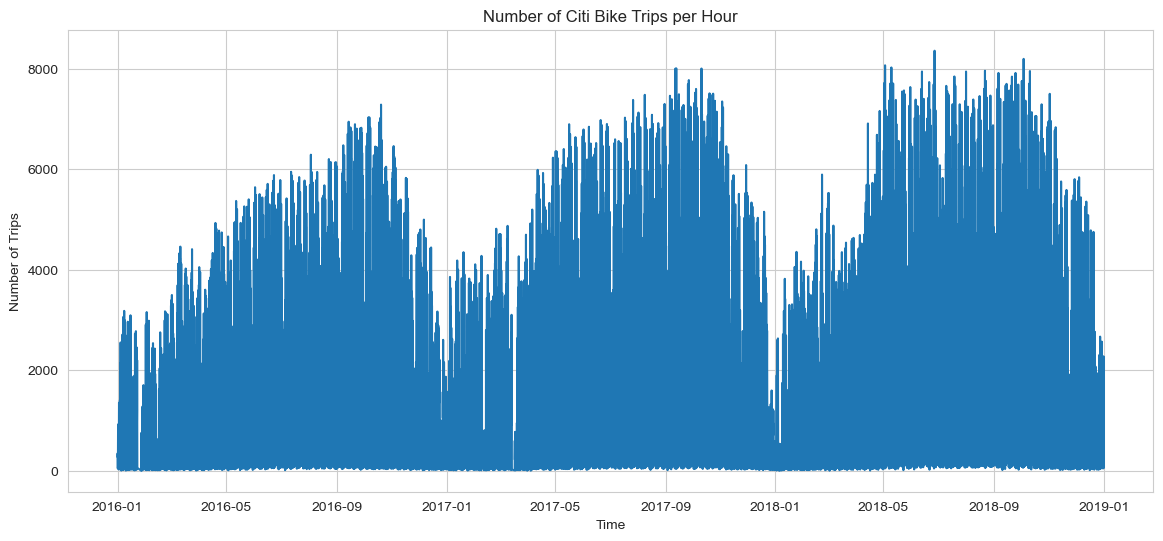

In [3]:
df = citibike.copy()

df["datetime_hour"] = df["start_time"].dt.floor("h")
hourly_counts = df["datetime_hour"].value_counts().sort_index()

plt.figure(figsize=(14, 6))
plt.plot(hourly_counts.index, hourly_counts.values)
plt.title("Number of Citi Bike Trips per Hour")
plt.xlabel("Time")
plt.ylabel("Number of Trips")
plt.show()

This plot shows a clear upward trend from 2016 to 2018, combined with strong seasonal variation. Trip counts are much lower in winter and much higher in spring, summer, and early autumn, while short-term fluctuations suggest the influence of commuting patterns, weekdays, and weather.

Overall, Citi Bike demand follows a structured pattern rather than random variation.

### 2. Plot: average number of trips by hour of the day

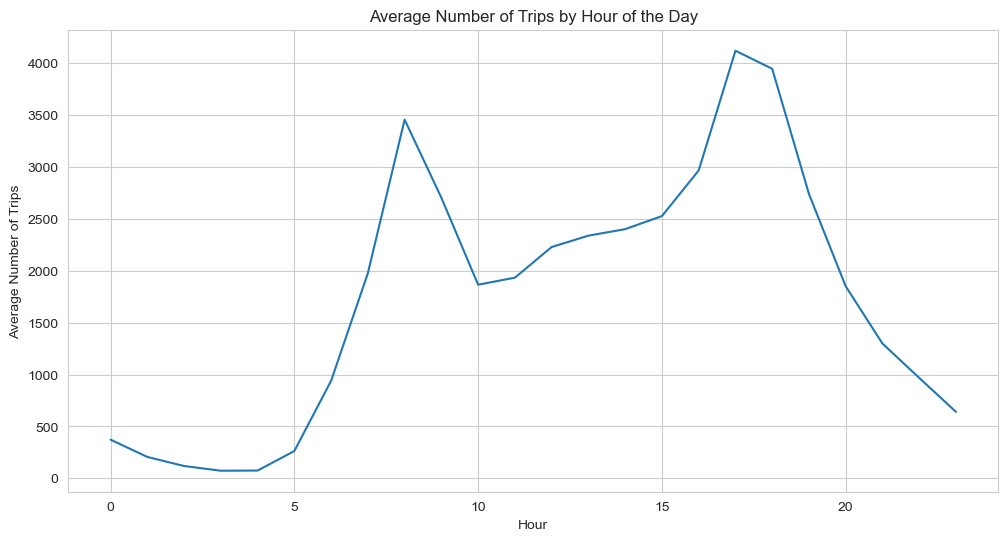

In [13]:
df = citibike.copy()

trip_counts = df["start_time"].dt.floor("h").value_counts()
hourly_avg = trip_counts.groupby(trip_counts.index.hour).mean()

plt.figure(figsize=(12, 6))
plt.plot(hourly_avg.index, hourly_avg.values)
plt.title("Average Number of Trips by Hour of the Day")
plt.xlabel("Hour")
plt.ylabel("Average Number of Trips")
plt.show()

Demand is lowest during the night, rises sharply in the early morning, and peaks around 8 AM and again around 5–6 PM. These two peaks strongly suggest commuting behavior, while daytime demand remains relatively high beyond rush hours.

This makes `hour` one of the strongest predictors of demand.

### 3. Plot: average number of trips by day of the week

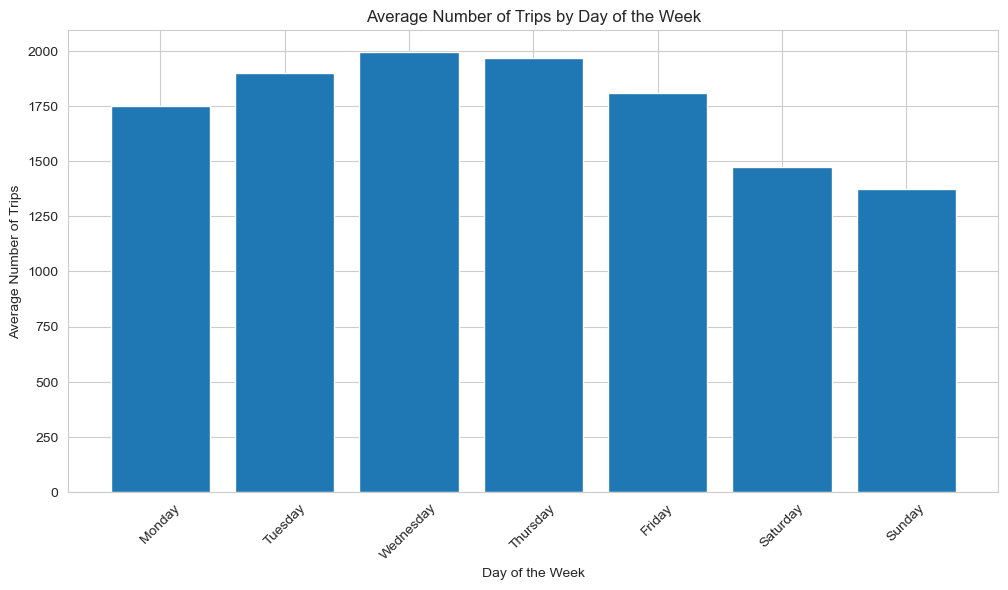

In [5]:
df = citibike.copy()

trip_counts = df["start_time"].dt.floor("h").value_counts()
weekday_avg = trip_counts.groupby(trip_counts.index.dayofweek).mean().sort_index()

weekday_labels = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

plt.figure(figsize=(12, 6))
plt.bar([weekday_labels[i] for i in weekday_avg.index], weekday_avg.values)
plt.title("Average Number of Trips by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Average Number of Trips")
plt.xticks(rotation=45)
plt.show()

Trip counts are highest during the middle of the workweek, especially on Wednesday and Thursday, and lower on weekends, with Sunday showing the lowest demand. This indicates that Citi Bike is mainly used for weekday mobility and commuting, while weekend usage is more likely linked to leisure or non-work travel.

The day of the week is therefore an important predictor of demand.

### 4. Plot: average number of trips by month

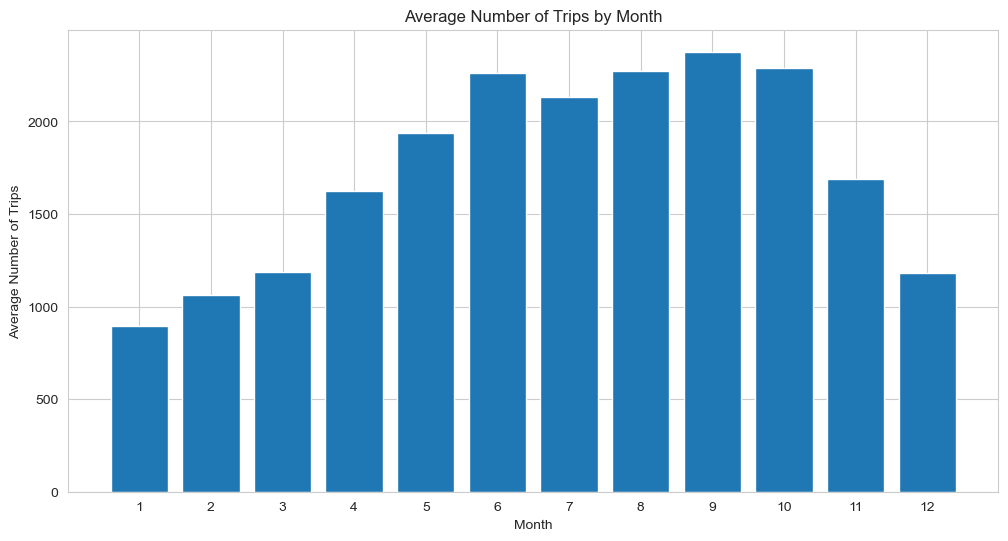

In [6]:
df = citibike.copy()

trip_counts = df["start_time"].dt.floor("h").value_counts()
month_avg = trip_counts.groupby(trip_counts.index.month).mean().sort_index()

plt.figure(figsize=(12, 6))
plt.bar(month_avg.index, month_avg.values)
plt.title("Average Number of Trips by Month")
plt.xlabel("Month")
plt.ylabel("Average Number of Trips")
plt.xticks(range(1, 13))
plt.show()

This plot reveals a strong annual cycle: demand is lowest in winter, increases through spring, and peaks in late summer or early autumn. This pattern shows that Citi Bike usage is strongly influenced by seasonality and weather conditions.

As a result, `month` is a valuable feature for forecasting.

### 5. Plot: rain vs no rain

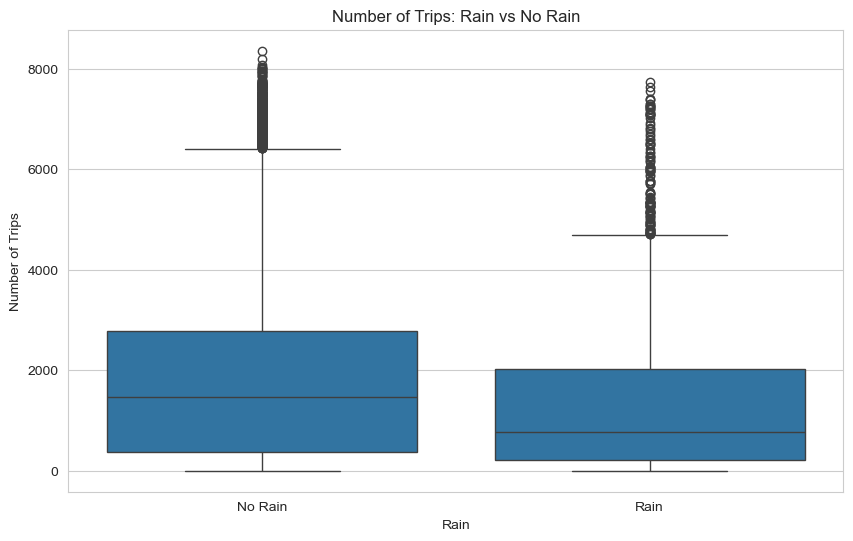

In [7]:
df = citibike.copy()

df["datetime_hour"] = df["start_time"].dt.floor("h")

rain_hourly_df = df.groupby("datetime_hour").agg(
    rain_mm=("rain", "mean"),
    trip_count=("start_time", "count")
).reset_index()

rain_hourly_df["is_raining"] = (rain_hourly_df["rain_mm"] > 0).astype(int)

plt.figure(figsize=(10, 6))
sns.boxplot(data=rain_hourly_df, x="is_raining", y="trip_count")
plt.title("Number of Trips: Rain vs No Rain")
plt.xlabel("Rain")
plt.ylabel("Number of Trips")
plt.xticks(ticks=[0, 1], labels=["No Rain", "Rain"])
plt.show()

The median number of trips is lower during rainy hours, and the whole rainy distribution is shifted slightly downward. However, the overlap between rainy and dry conditions shows that rain is not the only factor affecting demand.

Rain is therefore a useful predictor, but it should be combined with time-based and seasonal features.

### 6. Plot: trips by Hour - Weekday vs Weekend

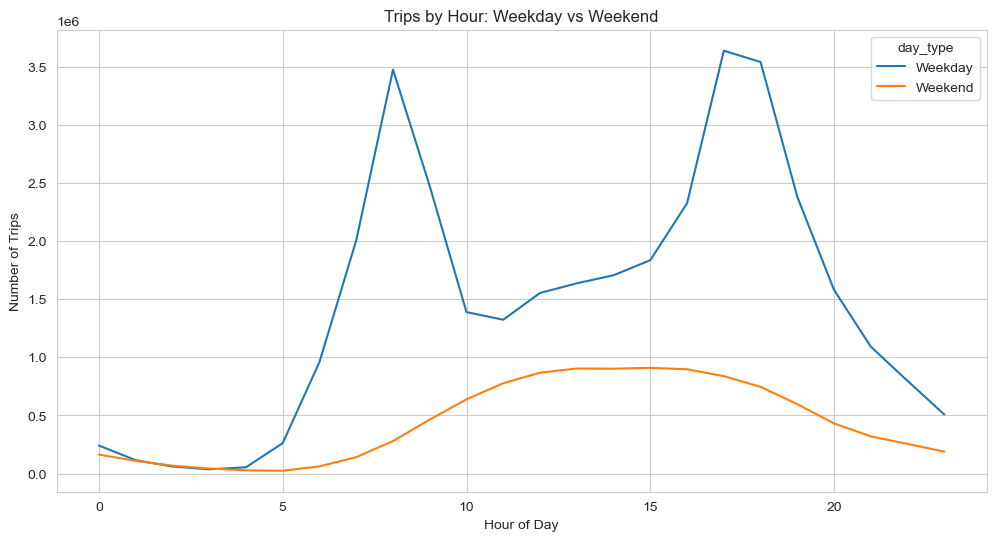

In [8]:
df = citibike.copy()

df["hour"] = df["start_time"].dt.hour
df["day_type"] = "Weekday"
df.loc[df["start_time"].dt.dayofweek >= 5, "day_type"] = "Weekend"

hourly_df = df.groupby(["hour", "day_type"]).size().reset_index(name="trip_count")

plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_df, x="hour", y="trip_count", hue="day_type")
plt.title("Trips by Hour: Weekday vs Weekend")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.show()

This graph clearly shows the difference between activity during the week and during the weekends. Looking at the data from during the week (the blue graph) we can clearly visualize the first peak around 8 in the morning, when most people go to work. After this peak the activity drops to a really low average before then climbing to the second peak of the day. This peak takes place around 5 in the afternoon when most people are done with work and are heading home. During the weekend (the orange graph) the trend is completely different. The amount of activity in the morning is really minimal and only starts climbing when we reach noon. After this, the trend holds for a few hours before going down. This can be caused by people sleeping in and only going for a bike trip in the afternoon when the temperature is at its highest, the trend really only starts to go down when the sun goes down in the evening. Another explanation for this behavior is tourism.

### 7. Plot: temperature vs number of trips

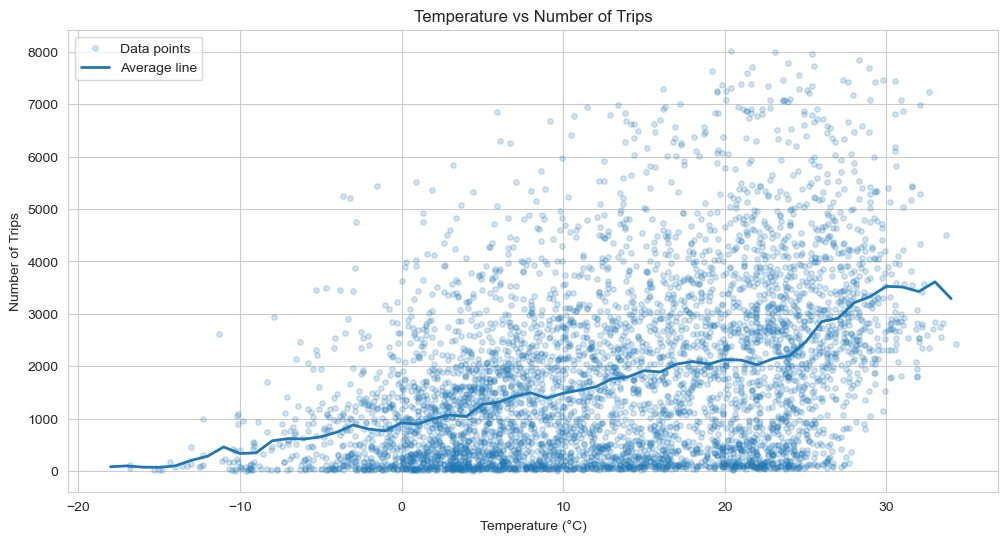

In [9]:
df = citibike.copy()

df["datetime_hour"] = df["start_time"].dt.floor("h")

temp_hourly_df = df.groupby("datetime_hour").agg(
    temperature=("temperature", "mean"),
    trip_count=("start_time", "count")
).reset_index()

sample_df = temp_hourly_df.sample(min(5000, len(temp_hourly_df)), random_state=42)
temp_avg = temp_hourly_df.groupby(temp_hourly_df["temperature"].round())["trip_count"].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.scatter(sample_df["temperature"], sample_df["trip_count"], alpha=0.2, s=15, label="Data points")
plt.plot(temp_avg["temperature"], temp_avg["trip_count"], linewidth=2, label="Average line")

plt.title("Temperature vs Number of Trips")
plt.xlabel("Temperature (°C)")
plt.ylabel("Number of Trips")
plt.legend()
plt.show()

This plot shows a clear positive relationship between temperature and bike demand. Warmer conditions are associated with more trips, while very high trip counts are rare in cold weather.

Since the spread remains wide, temperature is important but should be used together with other predictors.

### 8. Plot: trip duration distribution

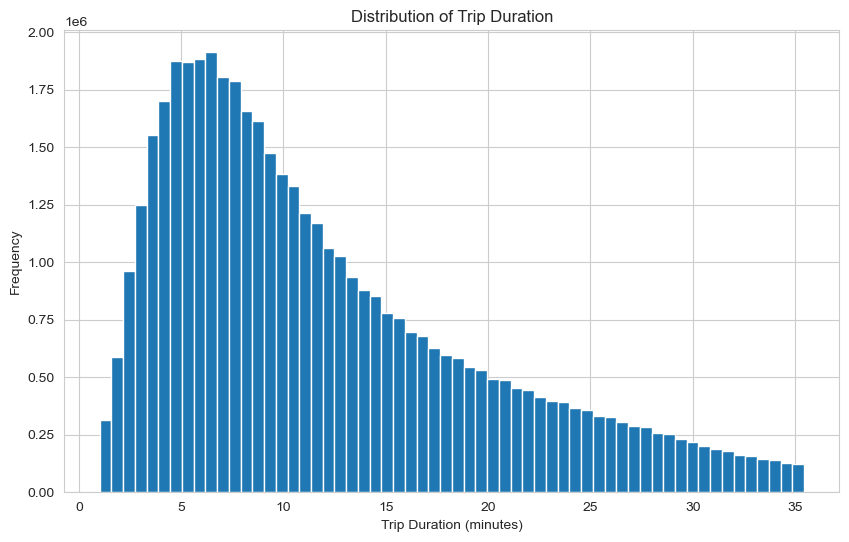

In [10]:
df = citibike.copy()
df = df[
    (df["trip_duration"] > 0) & 
    (df["trip_duration"] <= 10800)
]

df["trip_duration_min"] = df["trip_duration"] / 60.0

plt.figure(figsize=(10, 6))
plt.hist(df["trip_duration_min"], bins=60)
plt.title("Distribution of Trip Duration")
plt.xlabel("Trip Duration (minutes)")
plt.ylabel("Frequency")
plt.show()

Trip durations are strongly right-skewed: most rides are short, especially around 5 to 15 minutes, while long trips are relatively rare. This suggests that Citi Bike is mainly used for short urban travel rather than long-distance trips.

It also shows that trip duration is not normally distributed, which matters for later modeling.

### 9. Plot: user type distribution

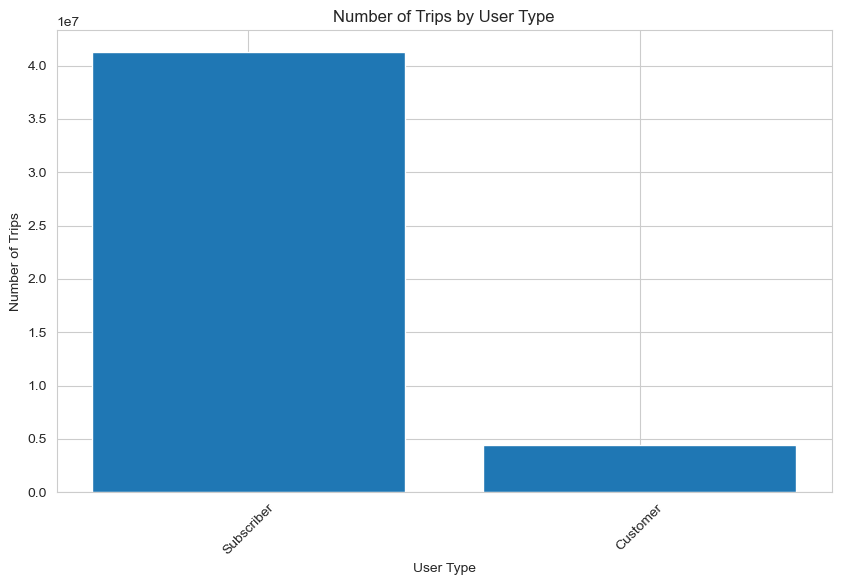

In [11]:
df = citibike.copy()

user_type_counts = df["user_type"].fillna("Unknown").value_counts()

plt.figure(figsize=(10, 6))
plt.bar(user_type_counts.index, user_type_counts.values)
plt.title("Number of Trips by User Type")
plt.xlabel("User Type")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.show()

Subscribers make far more trips than Customers, showing that Citi Bike is mainly used by regular rather than occasional riders. This suggests that the system primarily serves recurring daily mobility needs such as commuting.

User type therefore provides useful insight into overall demand patterns.

### 10. Plot: age category distribution

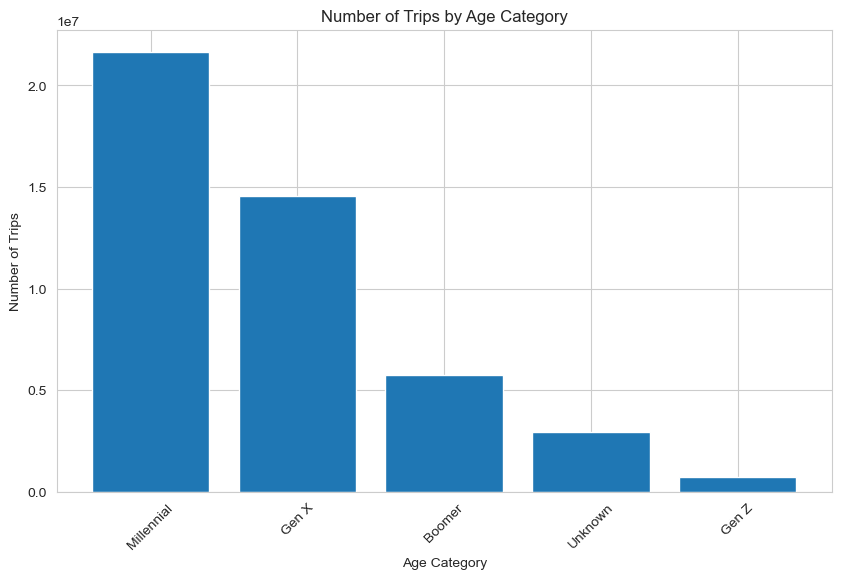

In [14]:
df = citibike.copy()

age_counts = df["age_category"].fillna("Unknown").value_counts()

plt.figure(figsize=(10, 6))
plt.bar(age_counts.index, age_counts.values)
plt.title("Number of Trips by Age Category")
plt.xlabel("Age Category")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.show()

Citi Bike usage is dominated by Millennials, followed by Gen X, while Boomers, Unknown, and Gen Z represent much smaller shares. This suggests that the system is used mainly by working-age adults.

That pattern fits well with the strong commuting signals found in the other visualizations.

### 11. Correlation matrix on hourly aggregated data

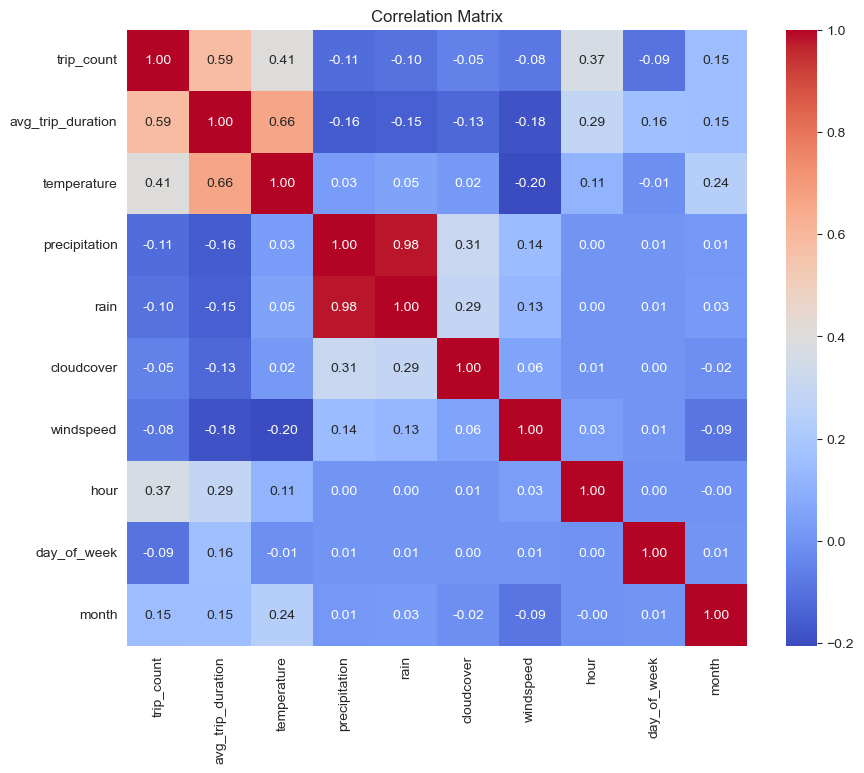

In [16]:
df = citibike.copy()

df["datetime_hour"] = df["start_time"].dt.floor("h")
df["trip_duration_min"] = df["trip_duration"] / 60.0

corr_df = df.groupby("datetime_hour").agg(
    trip_count=("start_time", "count"),
    avg_trip_duration=("trip_duration_min", "mean"),
    temperature=("temperature", "mean"),
    precipitation=("precipitation", "mean"),
    rain=("rain", "mean"),
    cloudcover=("cloudcover", "mean"),
    windspeed=("windspeed", "mean")
).reset_index()

corr_df["hour"] = corr_df["datetime_hour"].dt.hour
corr_df["day_of_week"] = corr_df["datetime_hour"].dt.dayofweek
corr_df["month"] = corr_df["datetime_hour"].dt.month

numeric_cols = [
    "trip_count", "avg_trip_duration", "temperature", "precipitation",
    "rain", "cloudcover", "windspeed", "hour", "day_of_week", "month"
]

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

The strongest positive correlations with trip_count are hour, temperature, and month, showing that time of day, weather, and season all matter. Rain-related variables have only weak negative correlations, while precipitation and rain are highly correlated with each other, indicating redundancy.

Overall, the matrix confirms that bike demand is influenced by multiple factors rather than one dominant variable.

### 12. Hourly trip volume heatmap

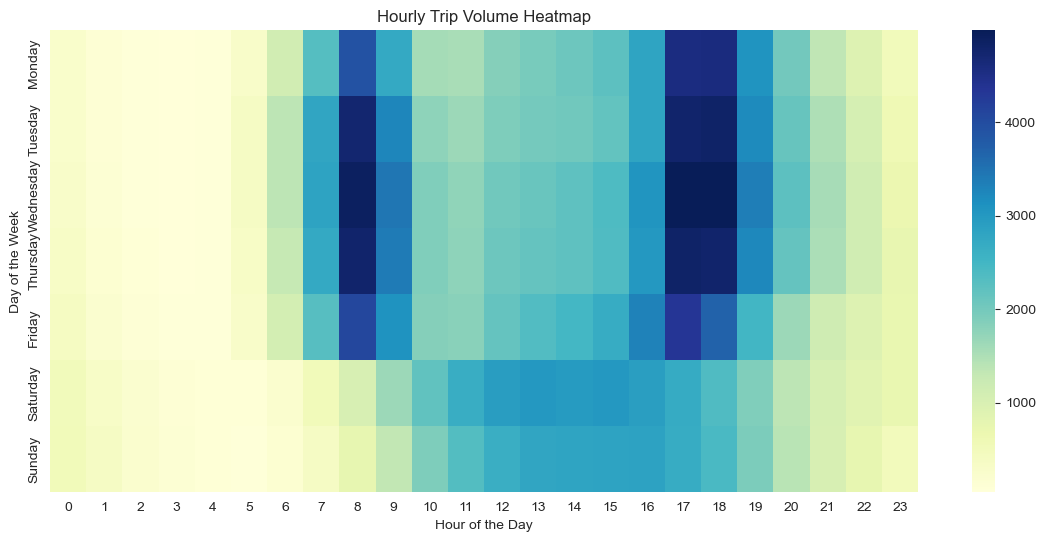

In [17]:
df = citibike.copy()

df["datetime_hour"] = df["start_time"].dt.floor("h")
df["hour"] = df["start_time"].dt.hour
df["weekday_num"] = df["start_time"].dt.dayofweek  # in pandas, 0 = Monday

hourly_counts = df.groupby(["datetime_hour", "hour", "weekday_num"]).size().reset_index(name="trip_count")

hourly_heatmap_df = hourly_counts.groupby(["hour", "weekday_num"])["trip_count"].mean().reset_index(name="avg_trip_count")

weekday_map = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}
hourly_heatmap_df["weekday_name"] = hourly_heatmap_df["weekday_num"].map(weekday_map)

heatmap_pivot = hourly_heatmap_df.pivot(
    index="weekday_name",
    columns="hour",
    values="avg_trip_count"
).reindex(list(weekday_map.values()))

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_pivot, cmap="YlGnBu")
plt.title("Hourly Trip Volume Heatmap")
plt.xlabel("Hour of the Day")
plt.ylabel("Day of the Week")
plt.show()

The heatmap highlights a strong contrast between weekdays and weekends. Weekdays show clear morning and evening commuting peaks, while weekends have a broader daytime pattern without a sharp morning peak.

This confirms that both hour and day_of_week are highly relevant for forecasting demand.

### 13. Weekly trip volume heatmap

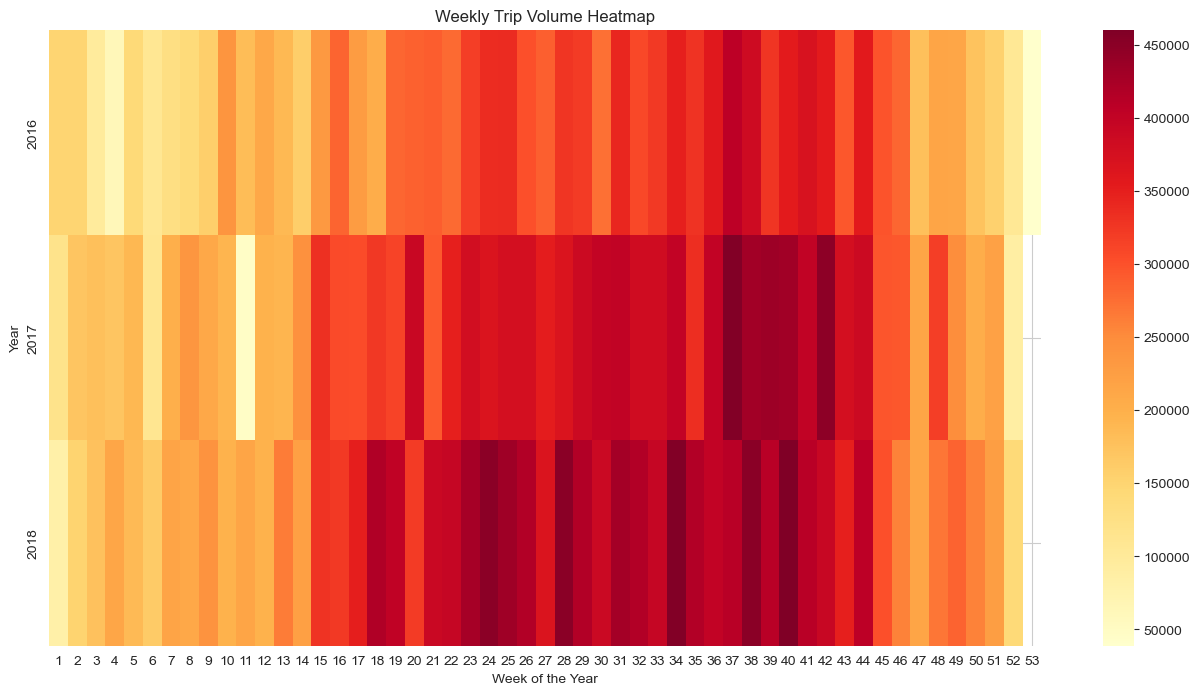

In [18]:
df = citibike.copy()

df["year"] = df["start_time"].dt.year
df["week"] = df["start_time"].dt.isocalendar().week

weekly_heatmap_df = df.groupby(["year", "week"]).size().reset_index(name="trip_count")

weekly_pivot = weekly_heatmap_df.pivot(
    index="year",
    columns="week",
    values="trip_count"
).sort_index()

plt.figure(figsize=(16, 8))
sns.heatmap(weekly_pivot, cmap="YlOrRd")
plt.title("Weekly Trip Volume Heatmap")
plt.xlabel("Week of the Year")
plt.ylabel("Year")
plt.show()

This heatmap shows both long-term growth and strong seasonality. Weekly demand is much lower in winter, much higher in warmer periods, and generally stronger in 2017 and 2018 than in 2016.

These patterns suggest that both week-level seasonal timing and year-over-year growth should be considered in the analysis.

### 14. Top 10 most popular start and end stations

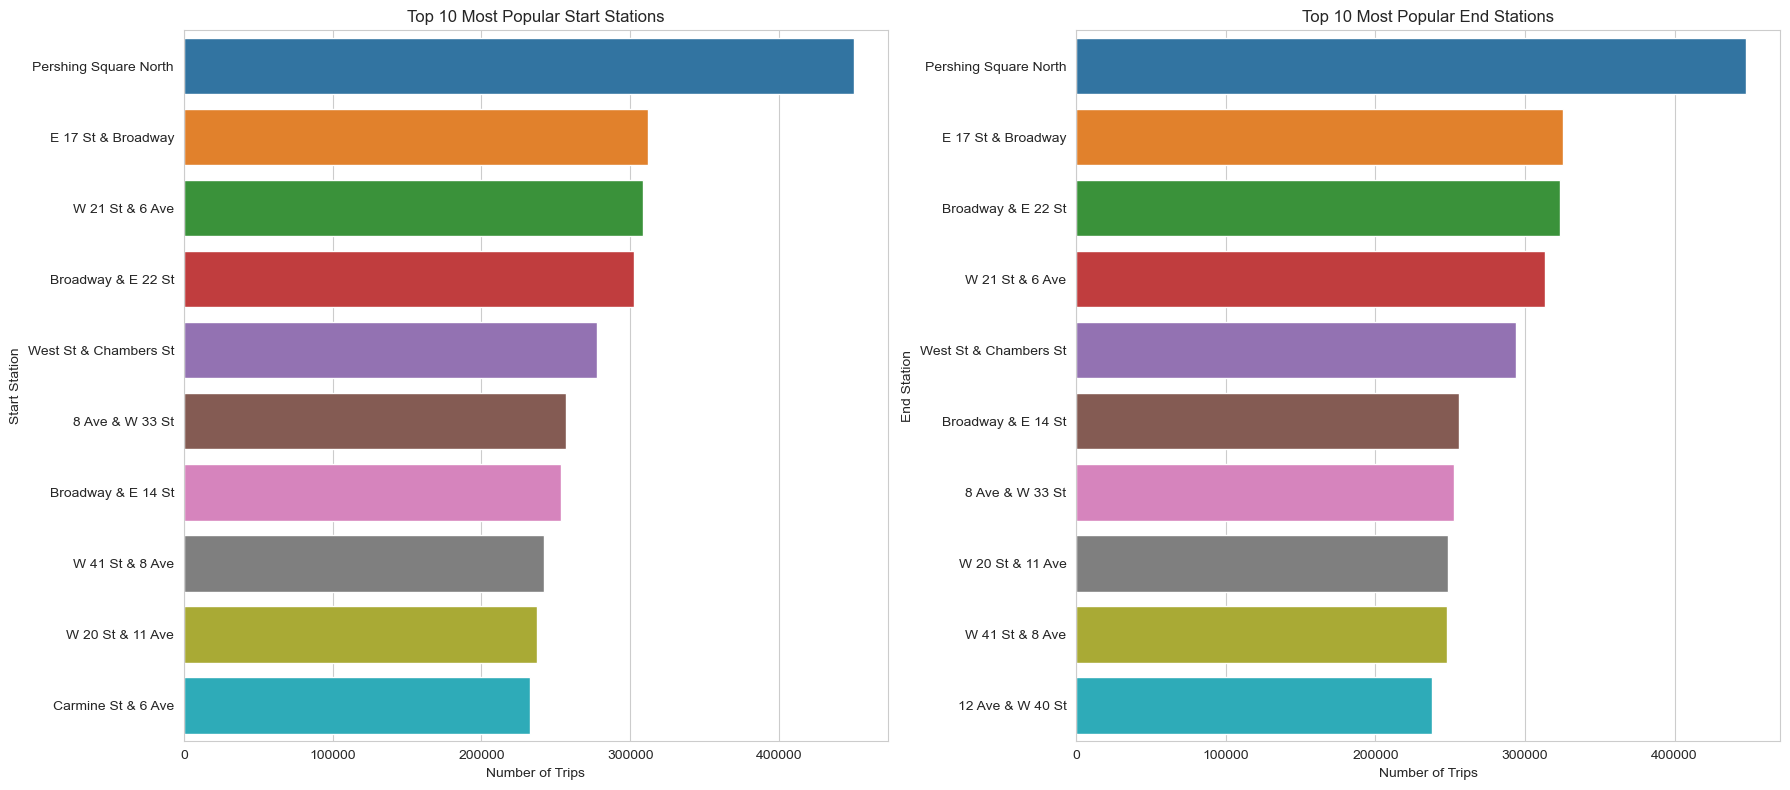

In [20]:
df = citibike.copy()

top_start_df = df.dropna(subset=["start_station_name"])["start_station_name"].value_counts().head(10).reset_index()
top_start_df.columns = ["start_station_name", "trip_count"]

top_end_df = df.dropna(subset=["end_station_name"])["end_station_name"].value_counts().head(10).reset_index()
top_end_df.columns = ["end_station_name", "trip_count"]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.barplot(
    data=top_start_df,
    y="start_station_name",
    x="trip_count",
    hue="start_station_name",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Top 10 Most Popular Start Stations")
axes[0].set_xlabel("Number of Trips")
axes[0].set_ylabel("Start Station")

sns.barplot(
    data=top_end_df,
    y="end_station_name",
    x="trip_count",
    hue="end_station_name",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Top 10 Most Popular End Stations")
axes[1].set_xlabel("Number of Trips")
axes[1].set_ylabel("End Station")

plt.tight_layout()
plt.show()

These charts show that usage is concentrated around a relatively small number of highly active stations. Pershing Square North stands out as the busiest station in both the start and end rankings, suggesting that it functions as a major hub in the network.

This highlights the importance of station location in understanding demand.

### 15. Geographic density map of station usage

In [21]:
df = citibike.copy()

starts = df[["start_station_id", "start_station_name", "start_station_latitude", "start_station_longitude"]].dropna()
starts.columns = ["station_id", "station_name", "latitude", "longitude"]

ends = df[["end_station_id", "end_station_name", "end_station_latitude", "end_station_longitude"]].dropna()
ends.columns = ["station_id", "station_name", "latitude", "longitude"]

station_usage = pd.concat([starts, ends], ignore_index=True)

station_density_df = station_usage.groupby(
    ["station_id", "station_name", "latitude", "longitude"]
).size().reset_index(name="usage_count")

station_density_df.head()

,station_id,station_name,latitude,longitude,usage_count
0,116,W 17 St & 8 Ave,40.741776,-74.001497,182805
1,119,Park Ave & St Edwards St,40.696089,-73.978034,17877
2,120,Lexington Ave & Classon Ave,40.686768,-73.959282,48516
3,127,Barrow St & Hudson St,40.731724,-74.006744,349963
4,128,MacDougal St & Prince St,40.727103,-74.002971,359182


In [25]:
nyc_center = [40.7128, -74.0060]

map = folium.Map(location=nyc_center, zoom_start=11)

heat_data = station_density_df[["latitude", "longitude", "usage_count"]].values.tolist()

HeatMap(
    heat_data,
    radius=12,
    blur=18,
    max_zoom=13
).add_to(map)

map

This map shows that station usage is spatially concentrated in Manhattan, especially in Midtown and Lower Manhattan. These areas appear as the strongest hotspots, suggesting that they function as major mobility hubs.

This confirms that Citi Bike demand is clustered around a limited number of central urban zones rather than evenly distributed across the network.

#### Explanation of how it was created

To create this map, both start stations and end stations were extracted from the dataset, together with their station IDs, names, and geographic coordinates. These records were combined so that the map reflects total station usage instead of only departures or only arrivals.

Next, the total number of occurrences per station was counted to create a `usage_count`. Finally, the station coordinates and their usage counts were visualized in an interactive heatmap using `folium` and the `HeatMap` plugin.
